# Exploratory Data Analysis: Social Media Crisis Dataset

This notebook explores `silver.csv` using standard EDA principles. The goal is to understand the data quality, distributions, relationships, crisis behavior, misinformation risk, credibility patterns, and engagement dynamics before modeling.

## 1. Setup

Import the main analysis libraries and set display options so tables and plots are easier to read.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../Medalian/Silver.csv")


## 2. Load the Dataset

Load the cleaned silver dataset and preview the first rows to understand the record structure.

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,post_id,platform,crisis_phase,topic,sentiment_label,sentiment_score,emotion,stance_label,claim_type,follower_count,following_count,account_age_days,verified_flag,source_type,is_share,parent_post_id,cascade_depth,likes,shares,comments,impressions_estimate,reach_estimate,engagement_velocity,misinformation_probability,credibility_score,uncertainty_index,subjectivity_score,toxicity_score,region,language,year,month,day
0,1,Twitter,Escalation,Service disruption,Neutral,-0.1080,Fear,Support,Opinion,5193,1712,2365,0,User,0,0.0000,0,653,276,345,30897,10254,7.8080,0.3080,0.7120,0.5030,0.7490,0.0360,Global,English,2025,June,Thursday
1,2,Reddit,Recovery,User complaints,Neutral,0.0630,Trust,Neutral,Fact Claim,1735,132,345,0,News Outlet,0,0.0000,0,1406,1068,494,34685,17812,20.3470,0.1100,0.7210,0.3960,0.5850,0.2400,Global,English,2025,August,Monday
2,3,Twitter,Peak,User complaints,Negative,-0.3640,Frustration,Question,Fact Claim,2933,2015,2431,0,User,0,0.0000,0,3204,300,1480,109789,45897,143.0450,0.7460,0.1050,0.6760,0.3720,0.4520,Global,English,2025,July,Saturday
3,4,Reddit,Response,Privacy concerns,Neutral,0.1760,Confusion,Criticize,Observation,891,59,882,0,Bot,0,0.0000,0,1889,90,10,39077,14778,31.0700,0.0950,0.7370,0.2390,0.2810,0.0220,Global,English,2025,August,Wednesday
4,5,Reddit,Recovery,Service disruption,Positive,0.5160,Trust,Criticize,Fact Claim,4445,1117,2314,0,User,0,0.0000,0,2300,685,424,71736,52714,21.4110,0.1470,0.8590,0.3560,0.4790,0.0820,Global,English,2025,July,Thursday


## 3. Dataset Shape and Column Types

Check the number of rows, number of columns, and the inferred data types. This helps separate numerical metrics from categorical descriptors.

In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "unique_values": df.nunique(dropna=True).values,
})
schema

Rows: 50,000
Columns: 33


,column,dtype,non_null_count,unique_values
0,post_id,int64,50000,50000
1,platform,str,50000,3
2,crisis_phase,str,50000,5
3,topic,str,50000,7
4,sentiment_label,str,50000,3
5,sentiment_score,float64,50000,1701
6,emotion,str,50000,6
7,stance_label,str,50000,4
8,claim_type,str,50000,4
9,follower_count,int64,50000,6768


## 4. Numerical Summary

Review central tendency, spread, and ranges for numerical variables. Large gaps between mean and max can indicate skewed behavior or outliers.

In [6]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,50000.0000,25000.5000,14433.9011,1.0000,12500.7500,25000.5000,37500.2500,50000.0000
sentiment_score,50000.0000,-0.1651,0.3877,-1.0000,-0.4390,-0.1450,0.1090,0.7000
follower_count,50000.0000,2153.6799,1615.1041,0.0000,867.0000,1828.0000,3110.0000,10495.0000
following_count,50000.0000,827.1928,616.3085,0.0000,334.0000,708.0000,1198.0000,4403.0000
account_age_days,50000.0000,1224.2071,903.3281,0.0000,500.0000,1053.0000,1775.0000,6119.0000
verified_flag,50000.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
is_share,50000.0000,0.2176,0.4126,0.0000,0.0000,0.0000,0.0000,1.0000
parent_post_id,50000.0000,2733.4339,7290.2363,0.0000,0.0000,0.0000,0.0000,49285.0000
cascade_depth,50000.0000,0.9838,2.1507,0.0000,0.0000,0.0000,0.0000,8.0000
likes,50000.0000,1962.0634,1541.0009,0.0000,856.0000,1715.0000,2566.0000,7500.0000


## 5. Categorical Summary

Inspect the most common categories. This identifies dominant platforms, crisis phases, topics, sentiments, source types, regions, and languages.

In [7]:
for column in ["platform","crisis_phase" , "topic", "sentiment_label", "emotion", "stance_label", "claim_type", "source_type", "region", "language"]:
    print(f"\n{column.upper()}")
    display(df[column].value_counts(dropna=False).head(10).to_frame("count"))


PLATFORM


,count
platform,
Reddit,16768
Facebook,16655
Twitter,16577



CRISIS_PHASE


,count
crisis_phase,
Escalation,12403
Response,10129
Peak,10090
Recovery,9888
Pre-Crisis,7490



TOPIC


...

,count
source_type,
User,34877
Influencer,5944
Bot,5005
News Outlet,4174



REGION


,count
region,
Global,50000



LANGUAGE


,count
language,
English,50000


## 6. Post Volume by Platform and Crisis Phase

Compare where crisis conversation is happening and which crisis phases are most active.

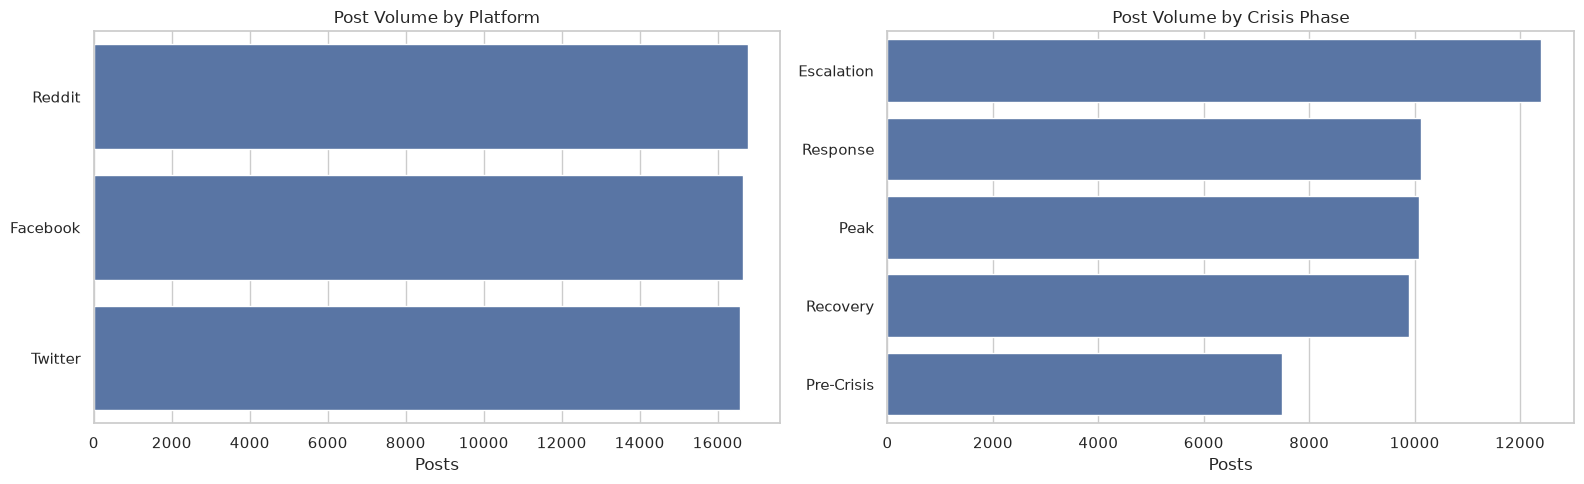

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, y="platform", order=df["platform"].value_counts().index, ax=axes[0])
axes[0].set_title("Post Volume by Platform")
axes[0].set_xlabel("Posts")
axes[0].set_ylabel("")

sns.countplot(data=df, y="crisis_phase", order=df["crisis_phase"].value_counts().index, ax=axes[1])
axes[1].set_title("Post Volume by Crisis Phase")
axes[1].set_xlabel("Posts")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Top Topics and Claim Types

Topics and claim types explain what people are talking about and how claims are framed.

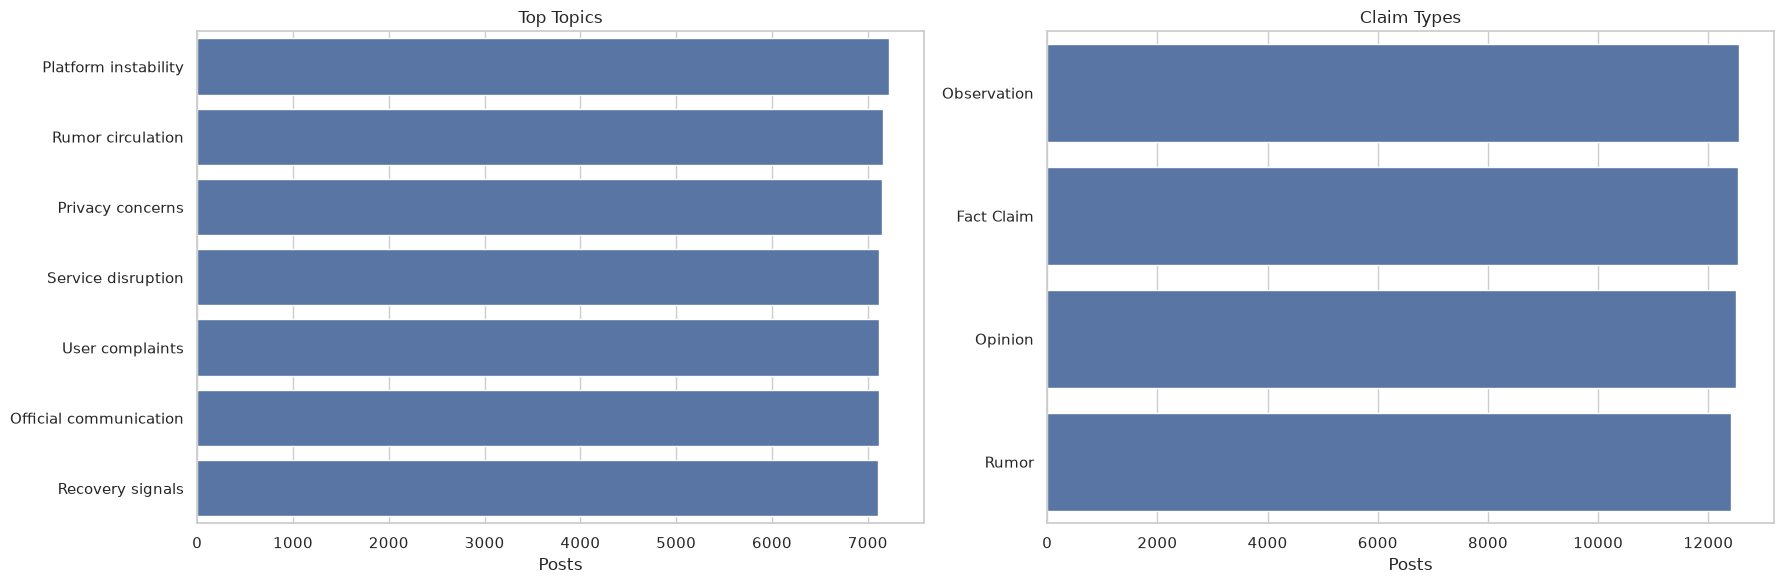

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot the 12 most common topics so the chart stays readable.
top_topic_order = df["topic"].value_counts().head(12).index
sns.countplot(data=df, y="topic", order=top_topic_order, ax=axes[0])
axes[0].set_title("Top Topics")
axes[0].set_xlabel("Posts")
axes[0].set_ylabel("")

# Plot every claim type because this field has only a few categories.
claim_type_order = df["claim_type"].value_counts().index
sns.countplot(data=df, y="claim_type", order=claim_type_order, ax=axes[1])
axes[1].set_title("Claim Types")
axes[1].set_xlabel("Posts")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



## 8. Sentiment, Emotion, and Stance

These fields describe the emotional and rhetorical tone of the crisis conversation.

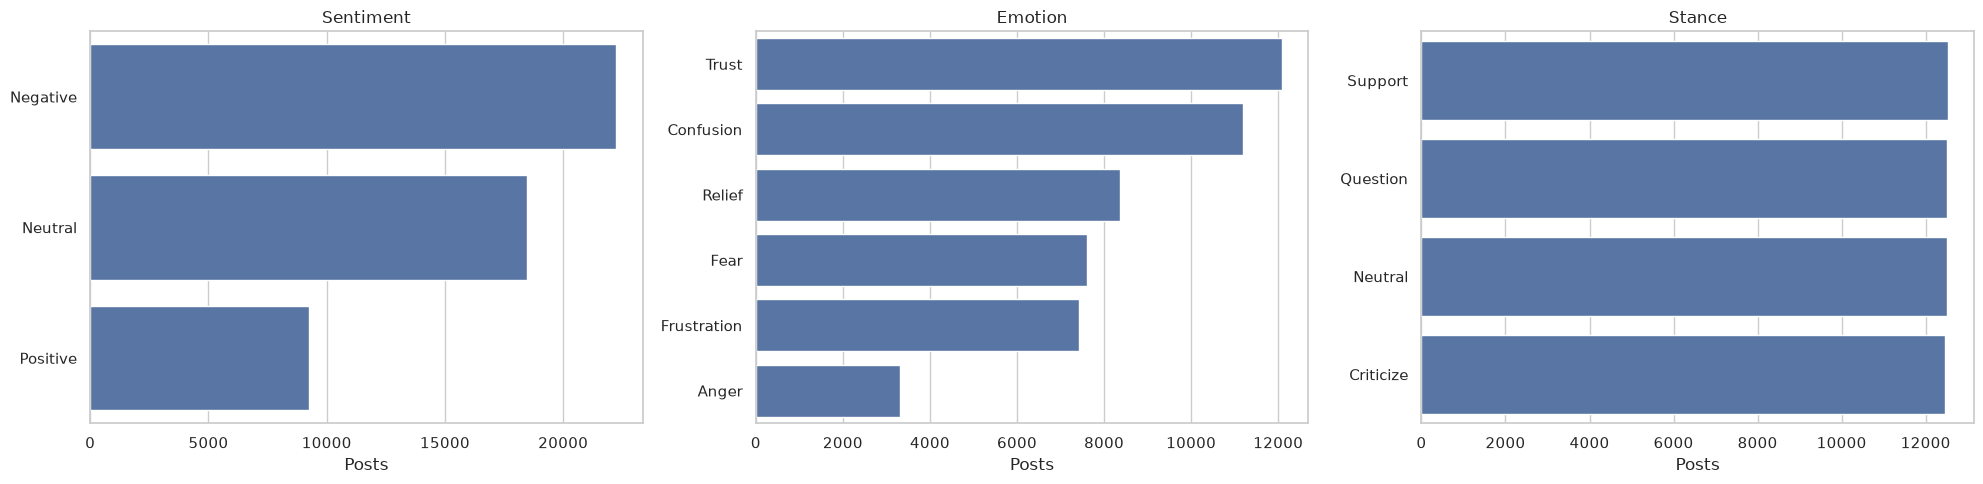

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for axis, column, title in zip(
    axes,
    ["sentiment_label", "emotion", "stance_label"],
    ["Sentiment", "Emotion", "Stance"],
):
    sns.countplot(data=df, y=column, order=df[column].value_counts().index, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Posts")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

## 9. Engagement Distributions

Engagement variables are often skewed. Log scaling helps reveal patterns without letting extreme values dominate the visual.

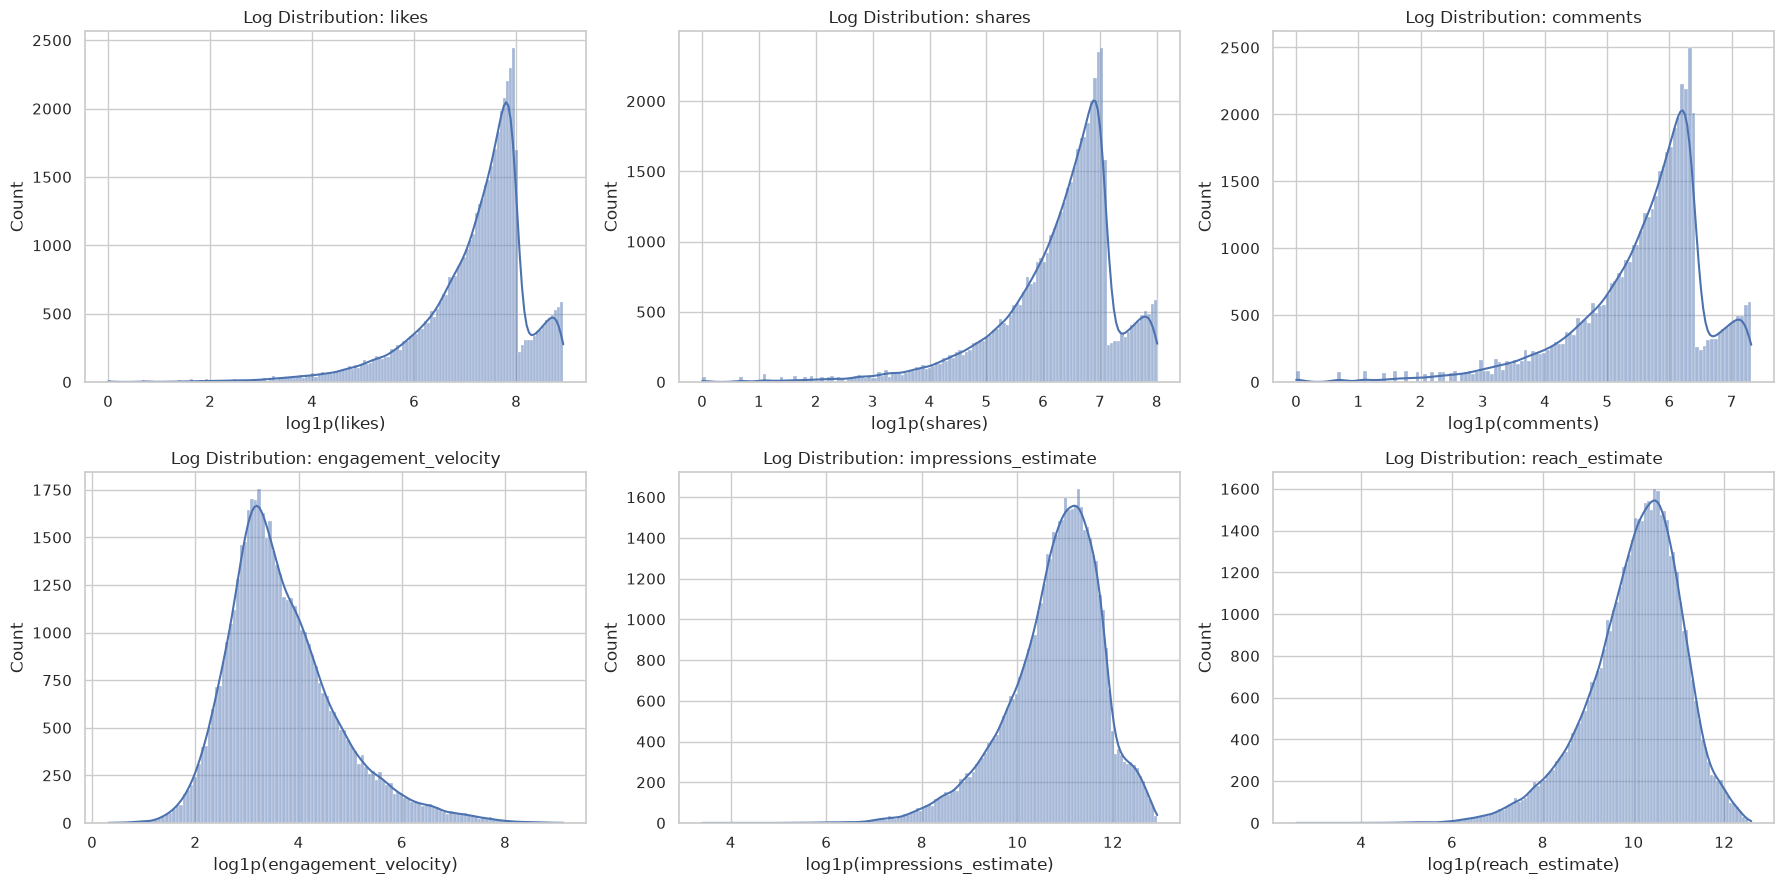

In [11]:
engagement_columns = ["likes", "shares", "comments", "engagement_velocity", "impressions_estimate", "reach_estimate"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, column in zip(axes.ravel(), engagement_columns):
    sns.histplot(np.log1p(df[column]), kde=True, ax=axis)
    axis.set_title(f"Log Distribution: {column}")
    axis.set_xlabel(f"log1p({column})")

plt.tight_layout()
plt.show()

## 10. Risk and Quality Distributions

These variables help evaluate content quality, uncertainty, subjectivity, toxicity, misinformation risk, and credibility.

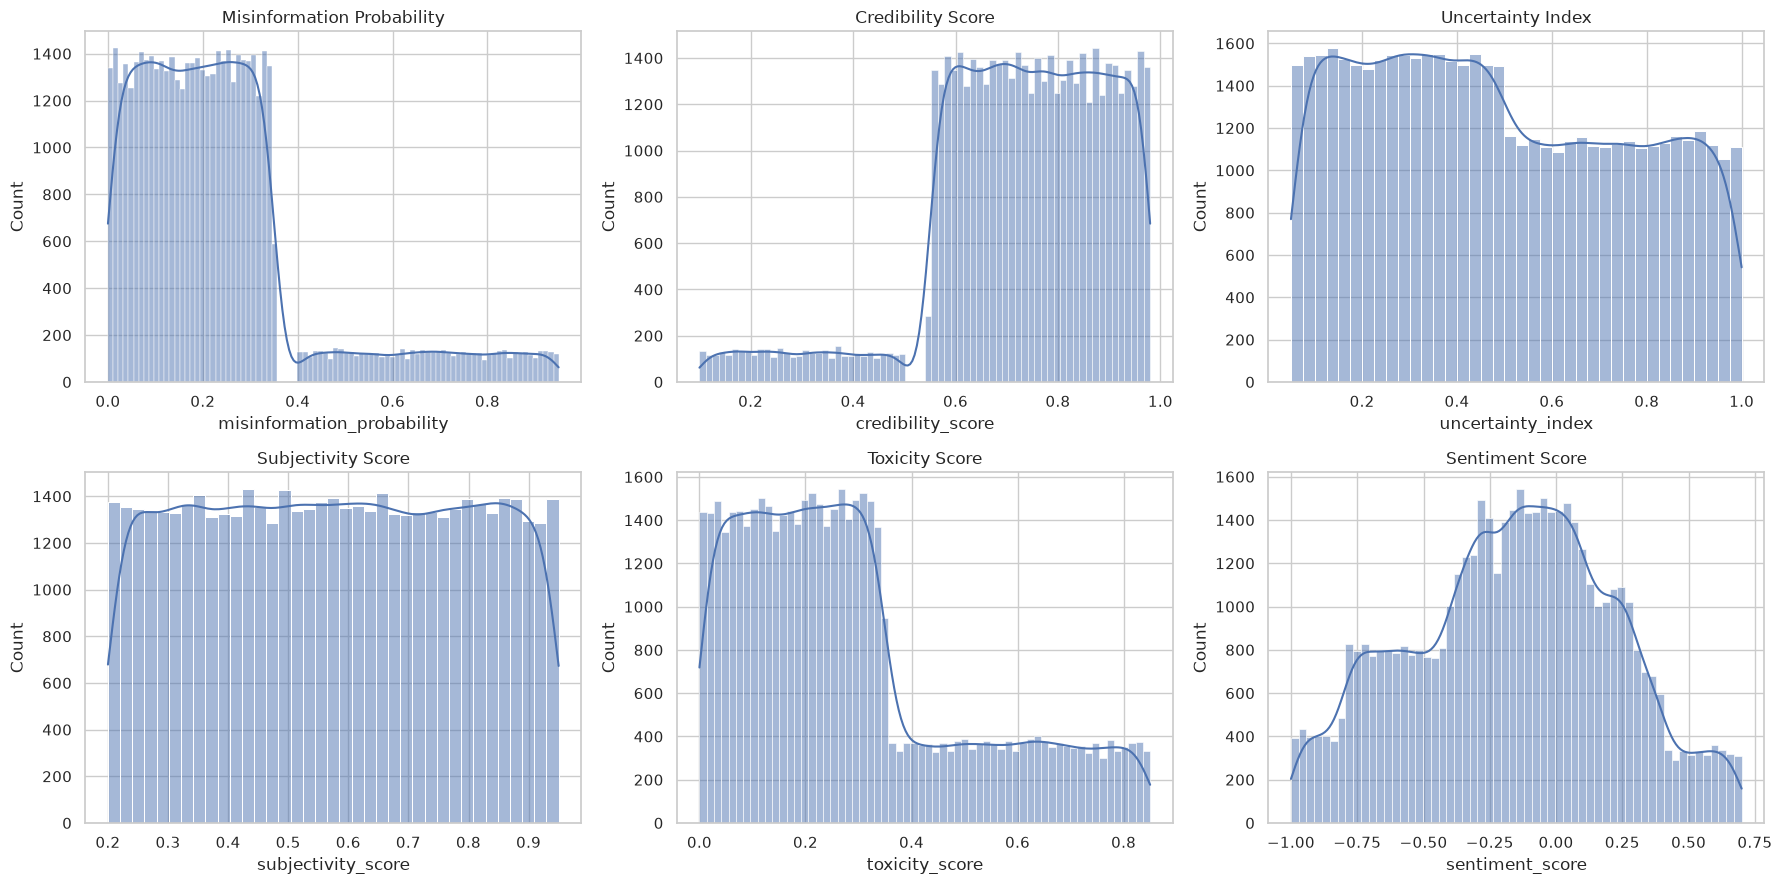

In [12]:
risk_columns = [
    "misinformation_probability",
    "credibility_score",
    "uncertainty_index",
    "subjectivity_score",
    "toxicity_score",
    "sentiment_score",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, column in zip(axes.ravel(), risk_columns):
    sns.histplot(df[column], kde=True, ax=axis)
    axis.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

## 11. Correlation Heatmap

Correlation helps identify linear relationships between engagement, reach, credibility, misinformation, and toxicity metrics.

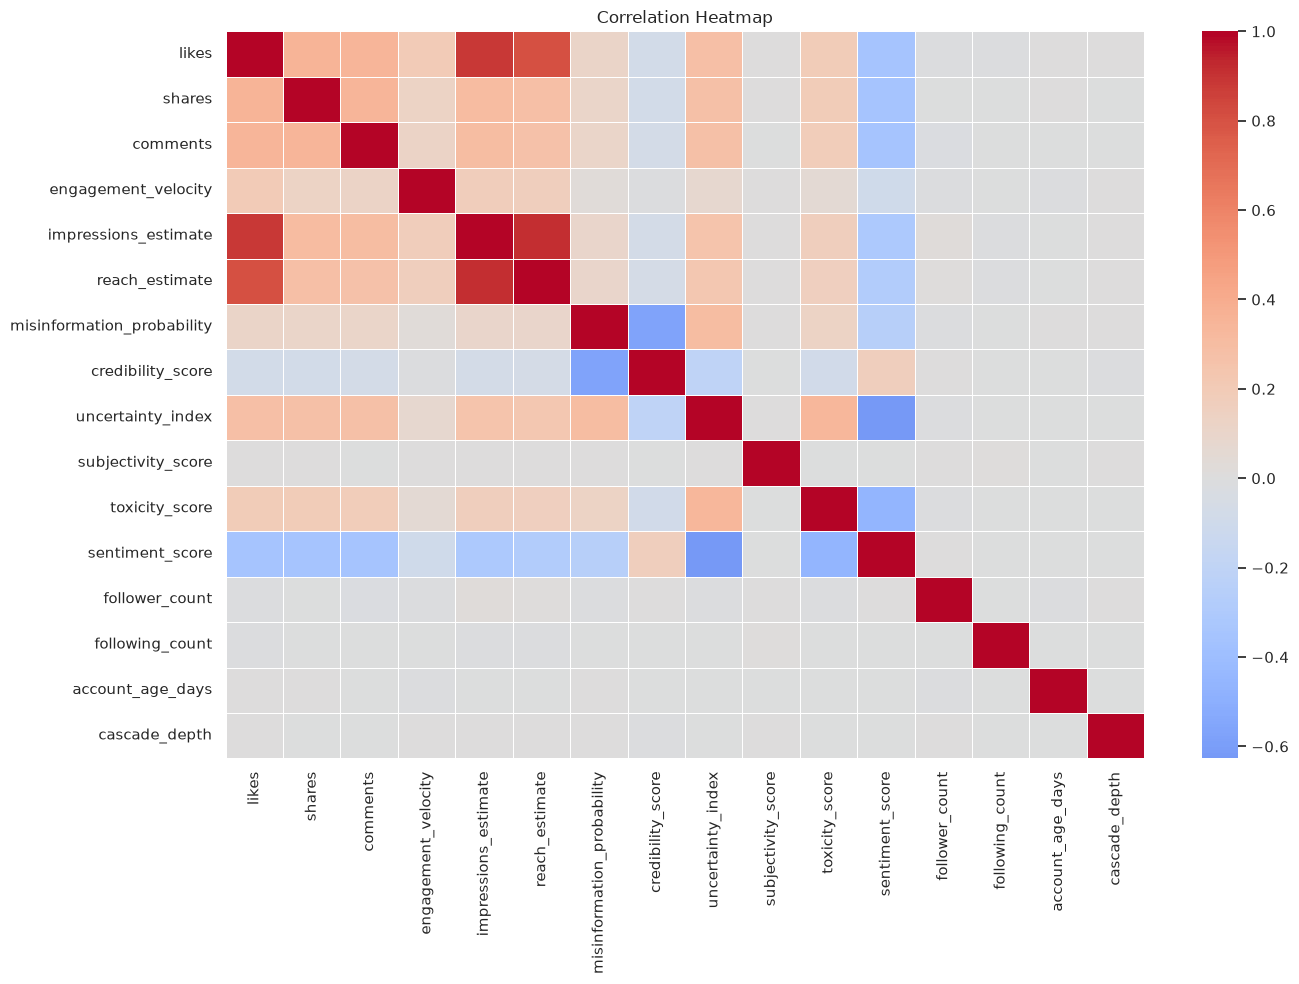

In [13]:
corr_columns = engagement_columns + risk_columns + ["follower_count", "following_count", "account_age_days", "cascade_depth"]
correlation = df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Engagement by Platform

Compare average engagement velocity by platform to see where content spreads fastest.

,platform,posts,avg_engagement_velocity,avg_misinformation,avg_credibility
0,Facebook,16655,91.3059,0.2377,0.7285
1,Reddit,16768,89.9916,0.2386,0.7260
2,Twitter,16577,89.4600,0.2364,0.7268


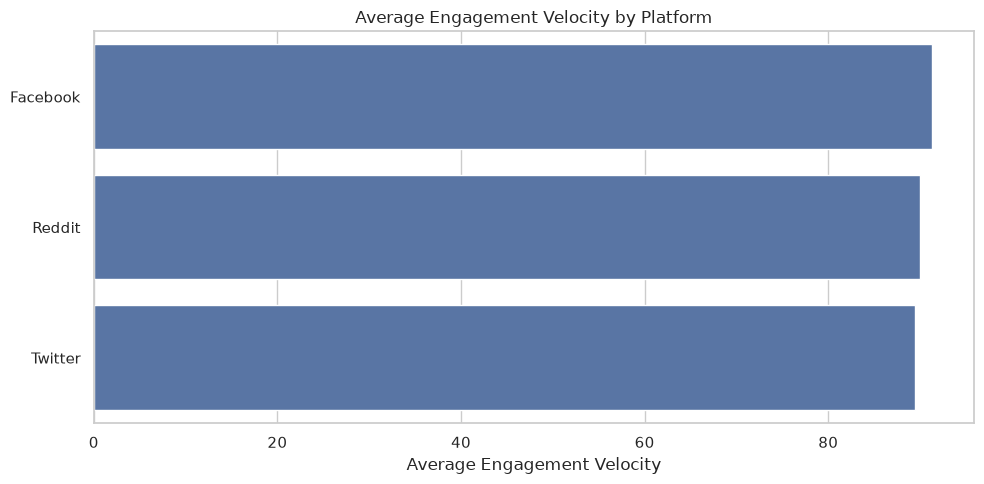

In [14]:
platform_engagement = (
    df.groupby("platform", as_index=False)
    .agg(
        posts=("post_id", "count"),
        avg_engagement_velocity=("engagement_velocity", "mean"),
        avg_misinformation=("misinformation_probability", "mean"),
        avg_credibility=("credibility_score", "mean"),
    )
    .sort_values("avg_engagement_velocity", ascending=False)
)

display(platform_engagement)

plt.figure(figsize=(10, 5))
sns.barplot(data=platform_engagement, x="avg_engagement_velocity", y="platform")
plt.title("Average Engagement Velocity by Platform")
plt.xlabel("Average Engagement Velocity")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 13. Misinformation and Credibility by Topic

Identify topics that carry higher misinformation risk or stronger credibility.

,topic,posts,avg_misinformation,avg_credibility,avg_toxicity
6,User complaints,7120,0.2403,0.7271,0.2872
4,Rumor circulation,7163,0.2393,0.7242,0.2882
5,Service disruption,7120,0.2379,0.7289,0.2892
2,Privacy concerns,7151,0.2378,0.7294,0.2836
3,Recovery signals,7102,0.2365,0.7250,0.2856
0,Official communication,7118,0.2361,0.7283,0.2858
1,Platform instability,7226,0.2350,0.7270,0.2869


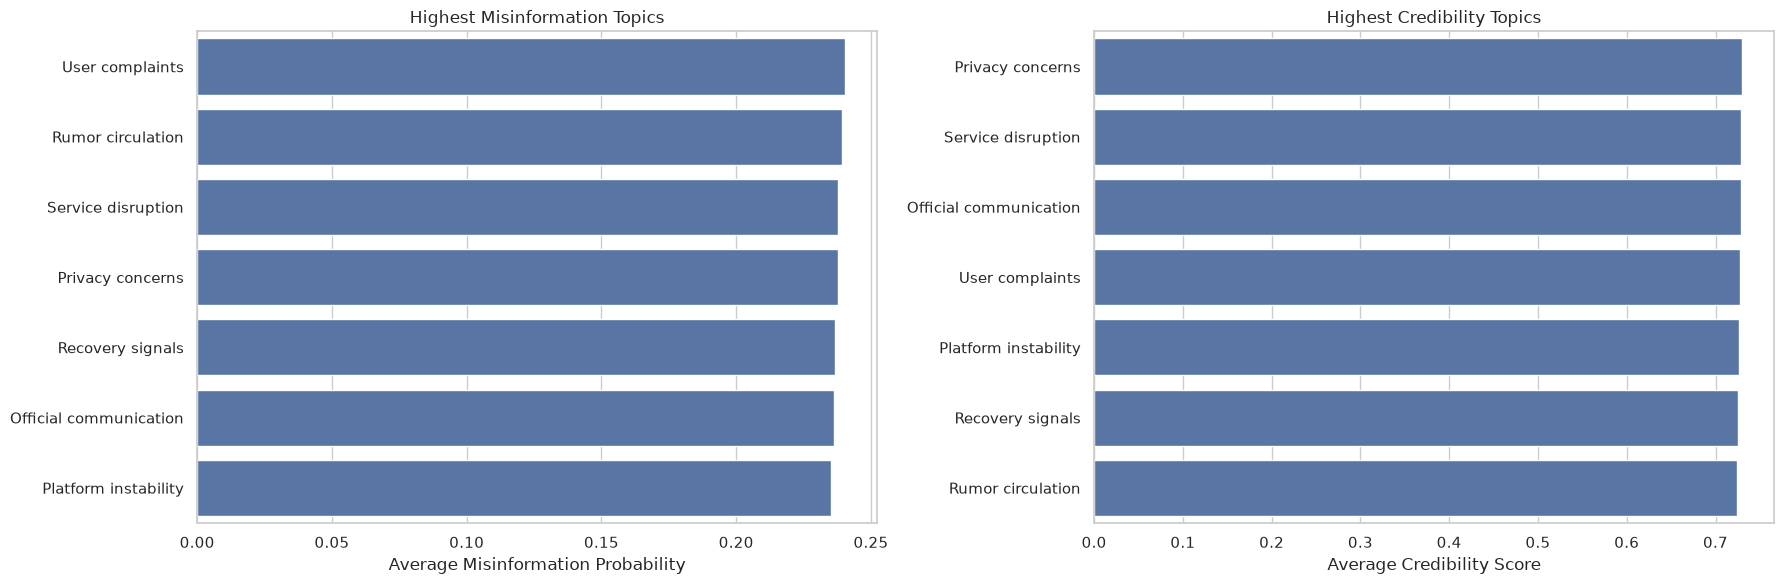

In [15]:
topic_risk = (
    df.groupby("topic", as_index=False)
    .agg(
        posts=("post_id", "count"),
        avg_misinformation=("misinformation_probability", "mean"),
        avg_credibility=("credibility_score", "mean"),
        avg_toxicity=("toxicity_score", "mean"),
    )
    .sort_values("avg_misinformation", ascending=False)
)

display(topic_risk.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=topic_risk.head(10), x="avg_misinformation", y="topic", ax=axes[0])
axes[0].set_title("Highest Misinformation Topics")
axes[0].set_xlabel("Average Misinformation Probability")
axes[0].set_ylabel("")

sns.barplot(data=topic_risk.sort_values("avg_credibility", ascending=False).head(10), x="avg_credibility", y="topic", ax=axes[1])
axes[1].set_title("Highest Credibility Topics")
axes[1].set_xlabel("Average Credibility Score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 14. Relationship Between Misinformation, Credibility, and Toxicity

These scatter plots show whether risky posts are also less credible, more toxic, or more engaging.

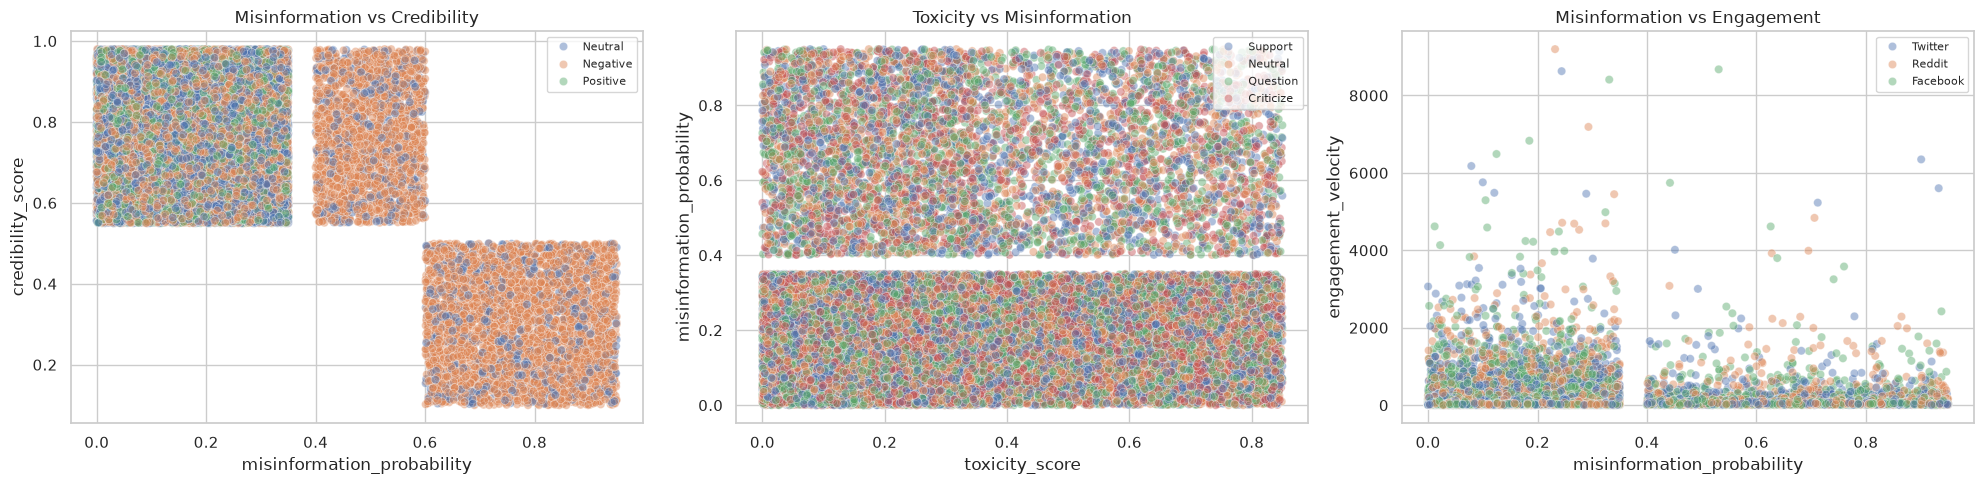

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(data=df, x="misinformation_probability", y="credibility_score", hue="sentiment_label", alpha=0.45, ax=axes[0])
axes[0].set_title("Misinformation vs Credibility")

sns.scatterplot(data=df, x="toxicity_score", y="misinformation_probability", hue="stance_label", alpha=0.45, ax=axes[1])
axes[1].set_title("Toxicity vs Misinformation")

sns.scatterplot(data=df, x="misinformation_probability", y="engagement_velocity", hue="platform", alpha=0.45, ax=axes[2])
axes[2].set_title("Misinformation vs Engagement")

for axis in axes:
    axis.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## 15. Time Patterns

The silver dataset stores year, month name, and weekday name. These views show how conversation changes by calendar attributes.

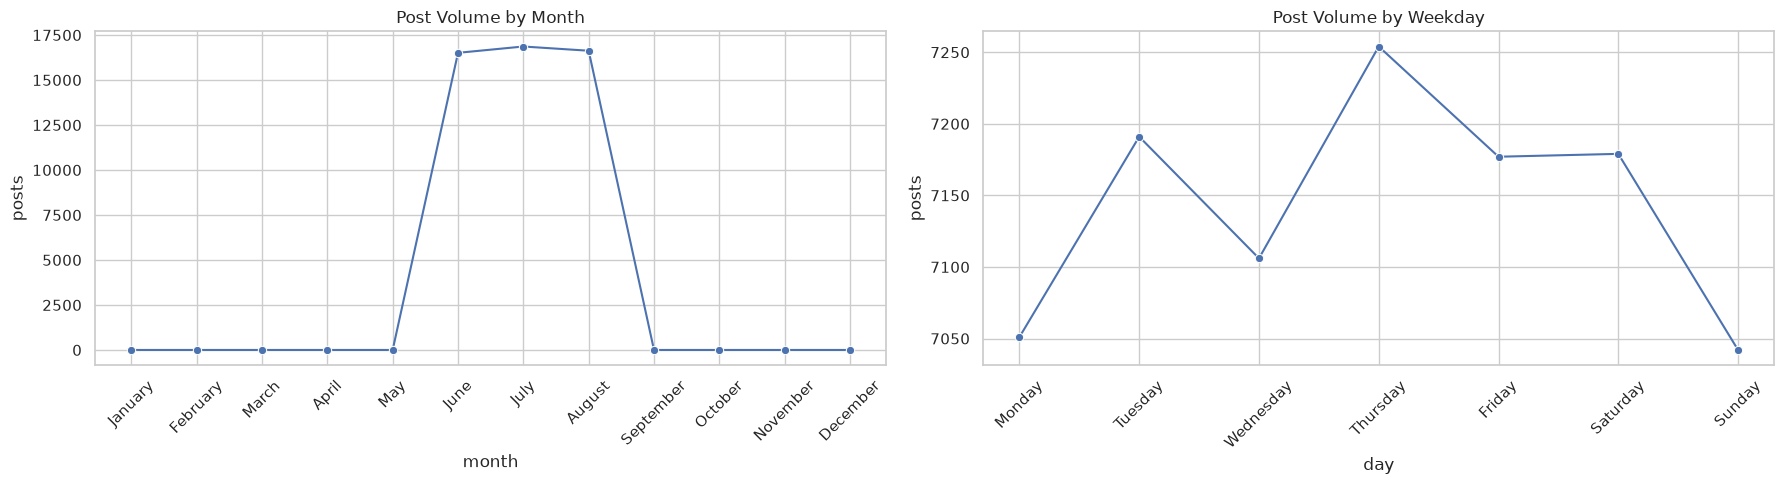

,month,posts,avg_misinformation,avg_engagement
0,January,0,NaN,NaN
1,February,0,NaN,NaN
2,March,0,NaN,NaN
3,April,0,NaN,NaN
4,May,0,NaN,NaN
5,June,16511,0.2359,89.7153
6,July,16862,0.2382,91.8327
7,August,16627,0.2385,89.1854
8,September,0,NaN,NaN
9,October,0,NaN,NaN


,day,posts,avg_misinformation,avg_engagement
0,Monday,7051,0.2376,87.0880
1,Tuesday,7191,0.2345,91.9069
2,Wednesday,7106,0.2382,93.1710
3,Thursday,7254,0.2424,88.8675
4,Friday,7177,0.2382,88.0074
5,Saturday,7179,0.2376,91.5354
6,Sunday,7042,0.2344,91.1982


In [17]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

monthly = (
    df.assign(month=pd.Categorical(df["month"], categories=month_order, ordered=True))
    .groupby("month", observed=False)
    .agg(posts=("post_id", "count"), avg_misinformation=("misinformation_probability", "mean"), avg_engagement=("engagement_velocity", "mean"))
    .reset_index()
)

weekday = (
    df.assign(day=pd.Categorical(df["day"], categories=day_order, ordered=True))
    .groupby("day", observed=False)
    .agg(posts=("post_id", "count"), avg_misinformation=("misinformation_probability", "mean"), avg_engagement=("engagement_velocity", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=monthly, x="month", y="posts", marker="o", ax=axes[0])
axes[0].set_title("Post Volume by Month")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=weekday, x="day", y="posts", marker="o", ax=axes[1])
axes[1].set_title("Post Volume by Weekday")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(monthly)
display(weekday)

## 16. Original Posts vs Shared Posts

Compare original and shared posts to see whether sharing behavior is associated with higher spread or risk.

,is_share,posts,avg_engagement,avg_misinformation,avg_credibility,avg_toxicity,post_type
0,0,39121,89.8038,0.2369,0.7278,0.2869,Original posts
1,1,10879,91.8691,0.2401,0.7249,0.2860,Shared posts


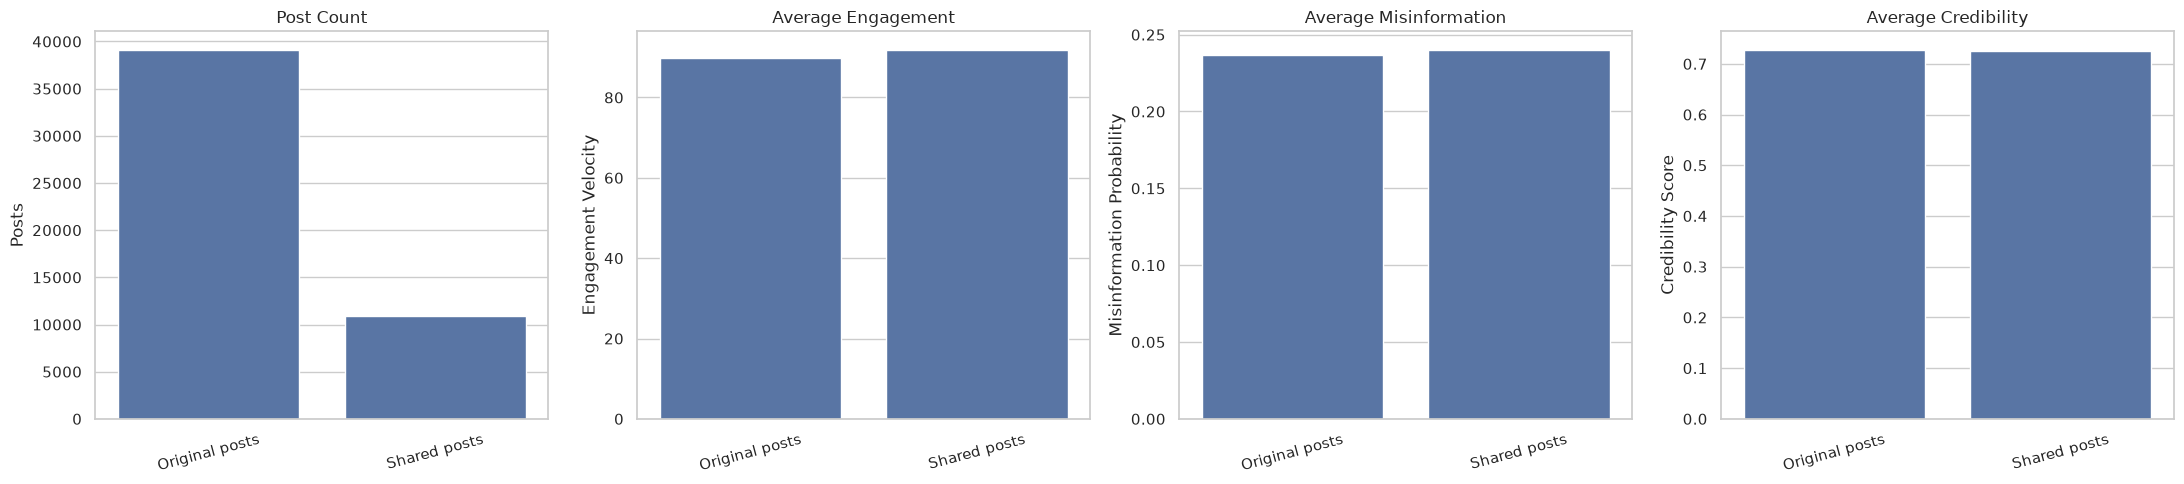

In [18]:
share_summary = (
    df.groupby("is_share", as_index=False)
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement_velocity", "mean"),
        avg_misinformation=("misinformation_probability", "mean"),
        avg_credibility=("credibility_score", "mean"),
        avg_toxicity=("toxicity_score", "mean"),
    )
)

# Make the labels easier to read in the chart.
share_summary["post_type"] = share_summary["is_share"].map({0: "Original posts", 1: "Shared posts"})
share_summary["post_type"] = share_summary["post_type"].fillna(share_summary["is_share"].astype(str))

display(share_summary)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

sns.barplot(data=share_summary, x="post_type", y="posts", ax=axes[0])
axes[0].set_title("Post Count")
axes[0].set_xlabel("")
axes[0].set_ylabel("Posts")

sns.barplot(data=share_summary, x="post_type", y="avg_engagement", ax=axes[1])
axes[1].set_title("Average Engagement")
axes[1].set_xlabel("")
axes[1].set_ylabel("Engagement Velocity")

sns.barplot(data=share_summary, x="post_type", y="avg_misinformation", ax=axes[2])
axes[2].set_title("Average Misinformation")
axes[2].set_xlabel("")
axes[2].set_ylabel("Misinformation Probability")

sns.barplot(data=share_summary, x="post_type", y="avg_credibility", ax=axes[3])
axes[3].set_title("Average Credibility")
axes[3].set_xlabel("")
axes[3].set_ylabel("Credibility Score")

for axis in axes:
    axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

